In [1]:
import os
import pandas as pd
import seaborn as sns
from itertools import product
from matplotlib import pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter

from polylex_chatbot.config import STATS_PATH, DATA_PATH, ARTICLE_PATTERN
from polylex_chatbot.env import load_project_env
from polylex_chatbot.metadata import load_metadata, build_language_matched_metadata_by_doc_id
from polylex_chatbot.chunking import create_chunks

/home/saskya/dev/tb/polylex-chatbot/.venv/lib/python3.12/site-packages/tika/__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
env_file = load_project_env(".env.20260702_test_baseline_but_qwen")
corpus_name = os.getenv("CORPUS_NAME")
metadata_dir = STATS_PATH / corpus_name
corpus_dir = DATA_PATH / corpus_name

In [3]:
metadata = load_metadata(metadata_dir)
language_matched_metadata_by_doc_id = build_language_matched_metadata_by_doc_id(metadata)

In [4]:
def compute_results(chunks):
    print(f"Nb chunks: {len(chunks)}")
    contents = [chunk.page_content for chunk in chunks]
    content_nb_chars = [len(content) for content in contents]

    plt.hist(content_nb_chars, bins=50)
    plt.xlabel("Nb chars")
    plt.ylabel("Frequency")
    plt.show()

    print(f"Min chunk len: {min(content_nb_chars)}")
    print(f"Max chunk len: {max(content_nb_chars)}")

In [5]:
def make_split_document_function(chunk_size, chunk_overlap, is_article_pattern_used):
    if is_article_pattern_used:
        separators = [
            ARTICLE_PATTERN,
            "\n\n",
            "\n",
            r"\.",
            " ",
            ""
        ]
    else:
        separators = [
            "\n\n",
            "\n",
            r"\.",
            " ",
            ""
        ]
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=separators,
        is_separator_regex=True,
        keep_separator=True,
        add_start_index=True
    )
    return splitter.split_documents

In [6]:
chunk_shapes = [
    {
        "name": "small",
        "chunk_size": 500,
        "chunk_overlap": 100
    },
    {
        "name": "medium",
        "chunk_size": 2000,
        "chunk_overlap": 300
    },
    {
        "name": "large",
        "chunk_size": 5000,
        "chunk_overlap": 500
    }
]

splitting_strategies = [
    {
        "name": "rcts_default",
        "is_article_pattern_used": False
    },
    {
        "name": "rcts_article_regex",
        "is_article_pattern_used": True
    }
]

chunk_contexts = [
    {
        "name": "content_only",
        "contextualize_chunk_function": lambda page_content, **kwargs: page_content
    },
    {
        "name": "title",
        "contextualize_chunk_function": lambda page_content, title=None, **kwargs: (
            f"{title}\n\n{page_content}" if title else page_content
        )
    },
    {
        "name": "title_description",
        "contextualize_chunk_function": lambda page_content, title=None, description=None, **kwargs: (
            "\n\n".join(
                part for part in [title, description, page_content]
                if part
            )
        )
    },
]

chunking_strategies = []

for chunk_shape, splitting_strategy, chunk_context in product(chunk_shapes, splitting_strategies, chunk_contexts):
    name = (
        f"{chunk_shape['name']}__"
        f"{splitting_strategy['name']}__"
        f"{chunk_context['name']}"
    )

    chunking_strategies.append({
        "name": name,

        "chunk_shape": chunk_shape["name"],
        "chunk_size": chunk_shape["chunk_size"],
        "chunk_overlap": chunk_shape["chunk_overlap"],

        "splitting_strategy": splitting_strategy["name"],
        "use_article_pattern": splitting_strategy["is_article_pattern_used"],

        "chunk_context": chunk_context["name"],
        "contextualize_chunk_function": chunk_context["contextualize_chunk_function"]
    })

In [7]:
chunking_results = {}

for i, strategy in enumerate(chunking_strategies, start=1):
    strategy_name = strategy["name"]
    print(f"Testing {strategy_name} ({i})")

    split_document_function = make_split_document_function(strategy["chunk_size"], strategy["chunk_overlap"], strategy["use_article_pattern"])

    chunks = create_chunks(corpus_dir, language_matched_metadata_by_doc_id, split_document_function=split_document_function, contextualize_chunk_function=strategy["contextualize_chunk_function"])

    chunking_results[strategy_name] = chunks

Testing small__rcts_default__content_only (1)
Testing small__rcts_default__title (2)
Testing small__rcts_default__title_description (3)
Testing small__rcts_article_regex__content_only (4)
Testing small__rcts_article_regex__title (5)
Testing small__rcts_article_regex__title_description (6)
Testing medium__rcts_default__content_only (7)
Testing medium__rcts_default__title (8)
Testing medium__rcts_default__title_description (9)
Testing medium__rcts_article_regex__content_only (10)
Testing medium__rcts_article_regex__title (11)
Testing medium__rcts_article_regex__title_description (12)
Testing large__rcts_default__content_only (13)
Testing large__rcts_default__title (14)
Testing large__rcts_default__title_description (15)
Testing large__rcts_article_regex__content_only (16)
Testing large__rcts_article_regex__title (17)
Testing large__rcts_article_regex__title_description (18)


In [11]:
print(len(chunking_results))

18


Results for small__rcts_default__content_only
Nb chunks: 13078


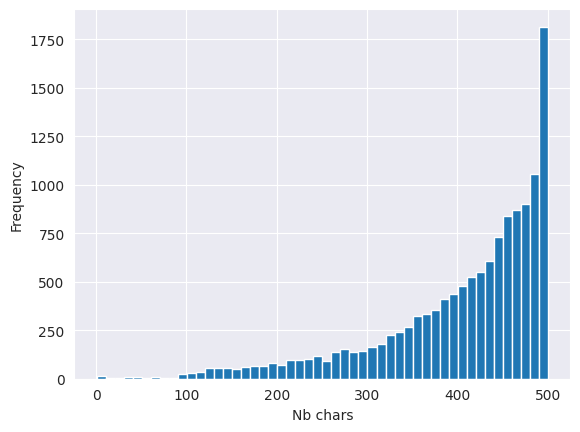

Min chunk len: 1
Max chunk len: 500
Results for small__rcts_default__title
Nb chunks: 13078


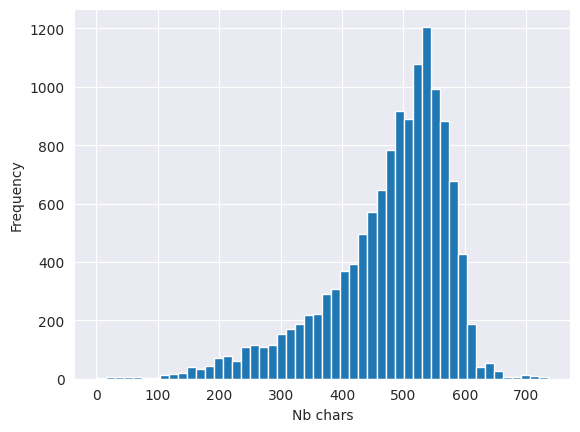

Min chunk len: 1
Max chunk len: 735
Results for small__rcts_default__title_description
Nb chunks: 13078


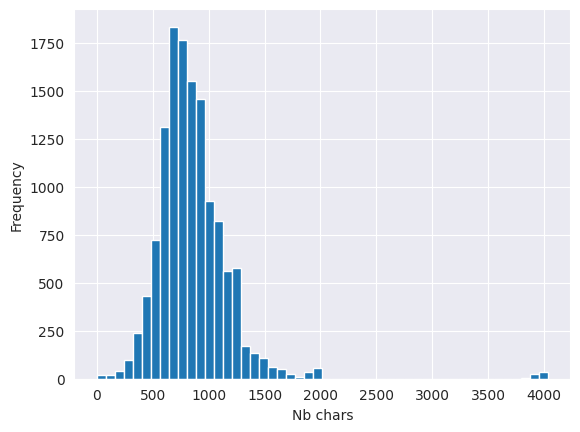

Min chunk len: 1
Max chunk len: 4035
Results for small__rcts_article_regex__content_only
Nb chunks: 13078


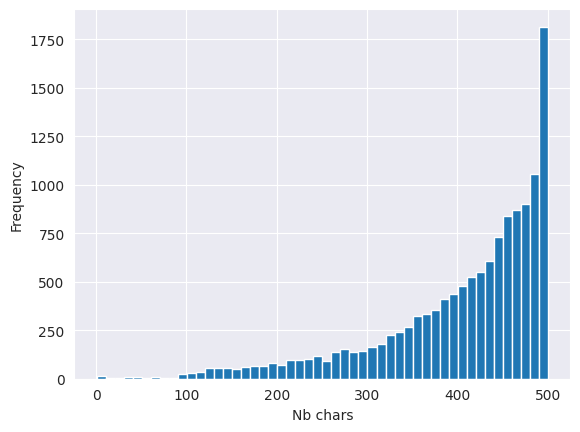

Min chunk len: 1
Max chunk len: 500
Results for small__rcts_article_regex__title
Nb chunks: 13078


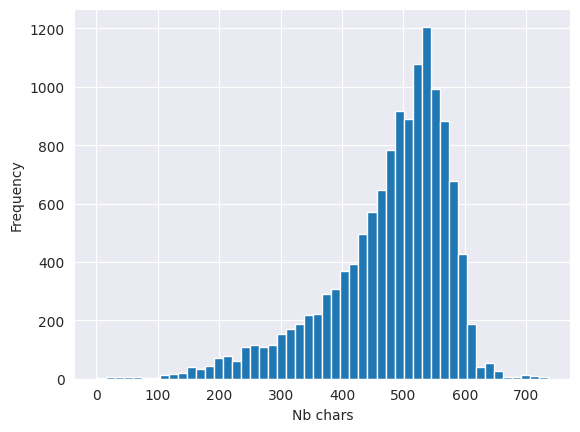

Min chunk len: 1
Max chunk len: 735
Results for small__rcts_article_regex__title_description
Nb chunks: 13078


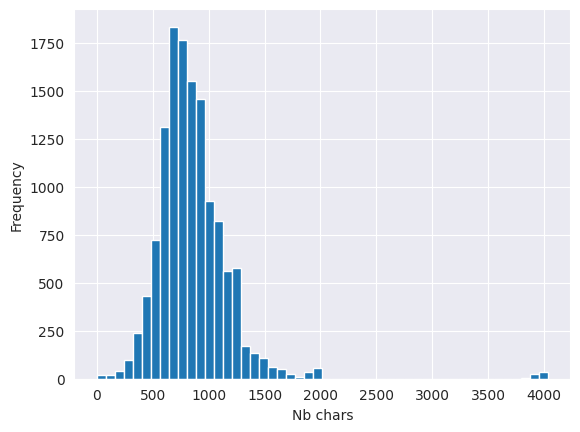

Min chunk len: 1
Max chunk len: 4035
Results for medium__rcts_default__content_only
Nb chunks: 3239


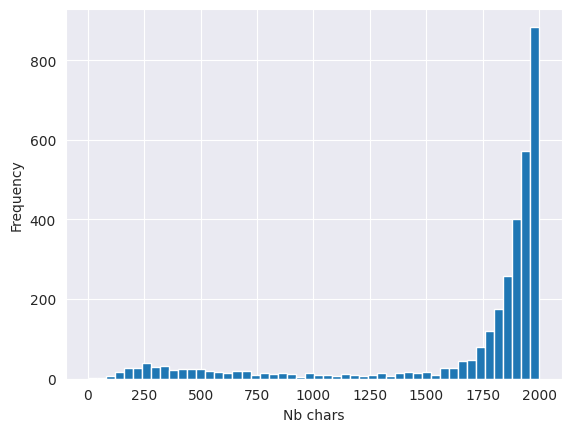

Min chunk len: 2
Max chunk len: 2000
Results for medium__rcts_default__title
Nb chunks: 3239


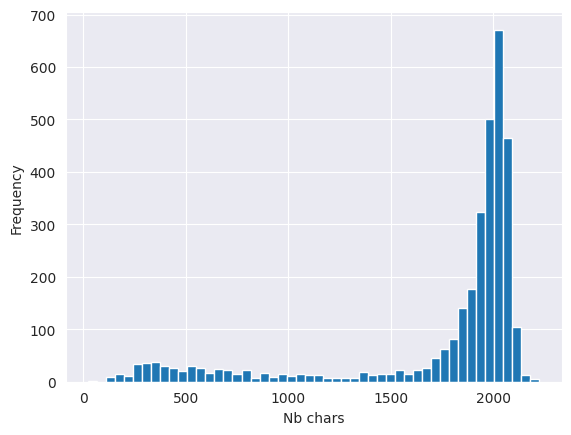

Min chunk len: 23
Max chunk len: 2223
Results for medium__rcts_default__title_description
Nb chunks: 3239


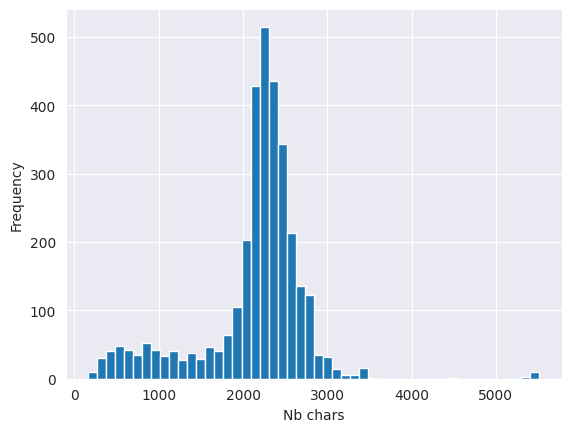

Min chunk len: 163
Max chunk len: 5513
Results for medium__rcts_article_regex__content_only
Nb chunks: 3239


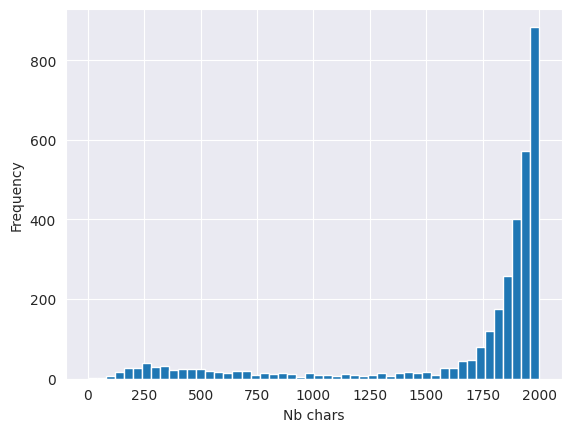

Min chunk len: 2
Max chunk len: 2000
Results for medium__rcts_article_regex__title
Nb chunks: 3239


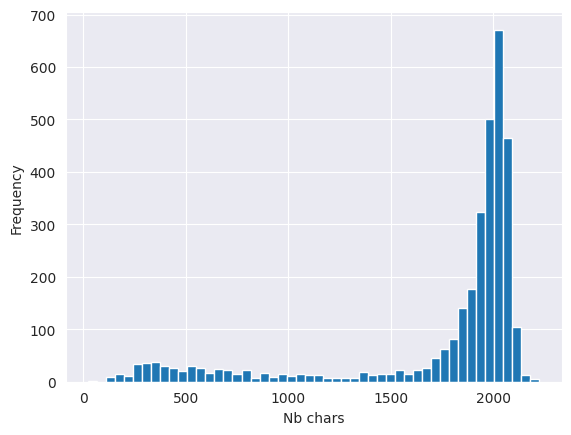

Min chunk len: 23
Max chunk len: 2223
Results for medium__rcts_article_regex__title_description
Nb chunks: 3239


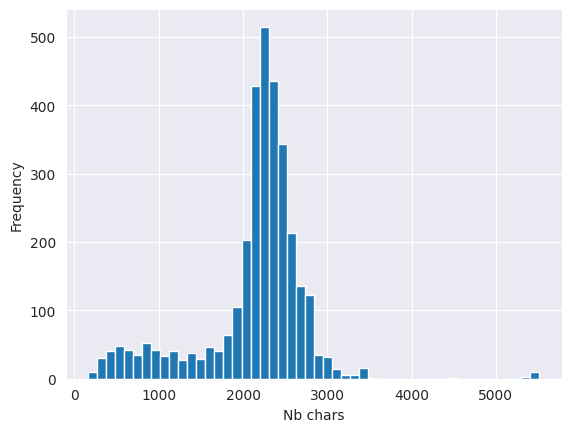

Min chunk len: 163
Max chunk len: 5513
Results for large__rcts_default__content_only
Nb chunks: 1483


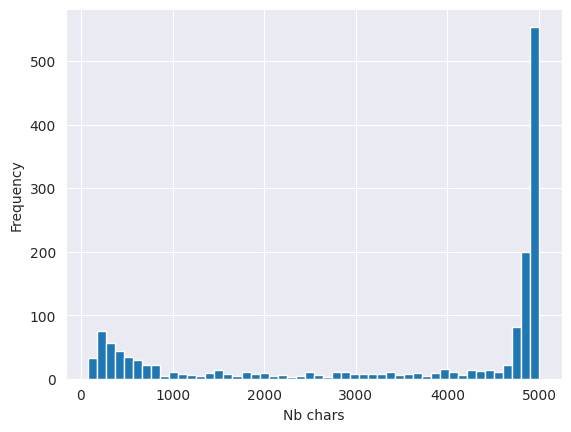

Min chunk len: 80
Max chunk len: 5000
Results for large__rcts_default__title
Nb chunks: 1483


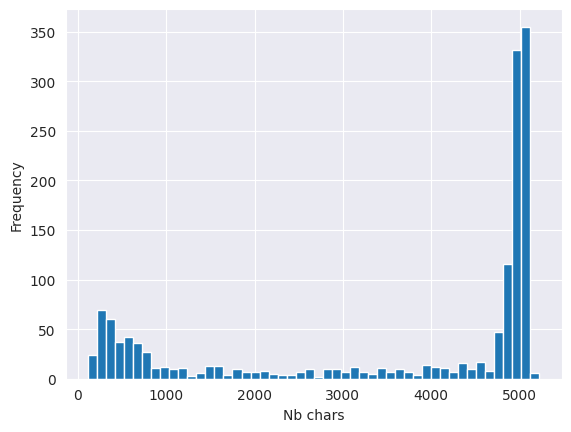

Min chunk len: 116
Max chunk len: 5221
Results for large__rcts_default__title_description
Nb chunks: 1483


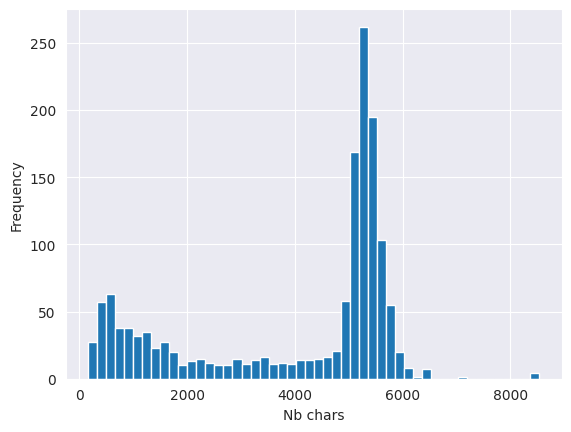

Min chunk len: 163
Max chunk len: 8536
Results for large__rcts_article_regex__content_only
Nb chunks: 1483


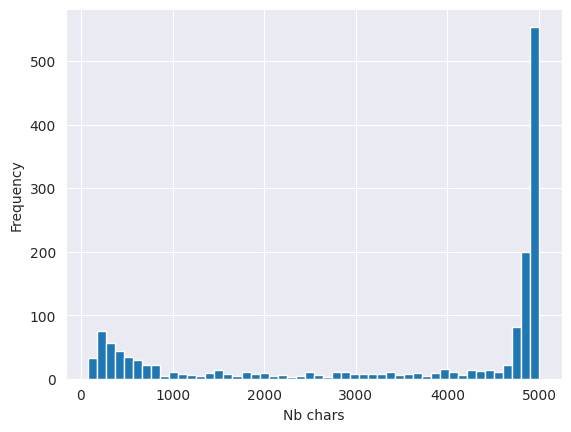

Min chunk len: 80
Max chunk len: 5000
Results for large__rcts_article_regex__title
Nb chunks: 1483


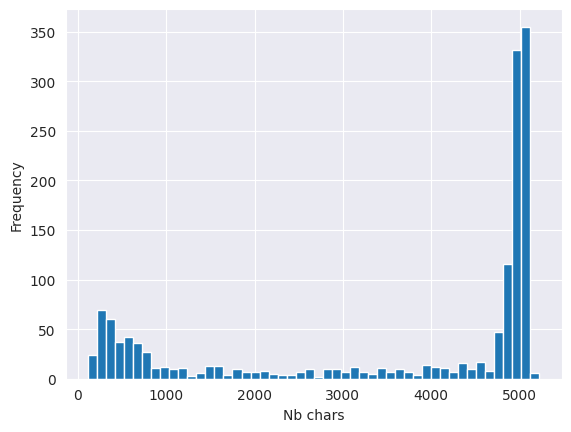

Min chunk len: 116
Max chunk len: 5221
Results for large__rcts_article_regex__title_description
Nb chunks: 1483


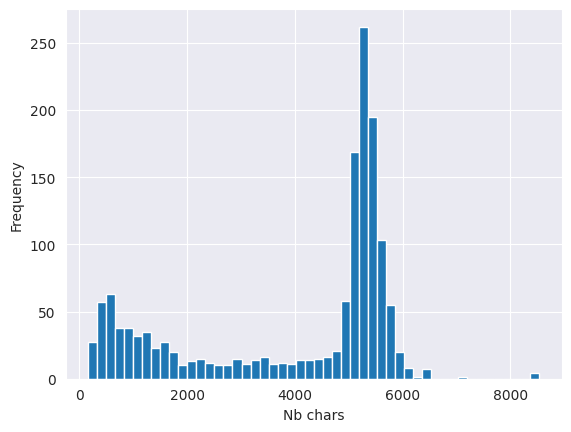

Min chunk len: 163
Max chunk len: 8536


In [12]:
for strategy_name, chunks in chunking_results.items():
    print(f"Results for {strategy_name}")
    compute_results(chunks)

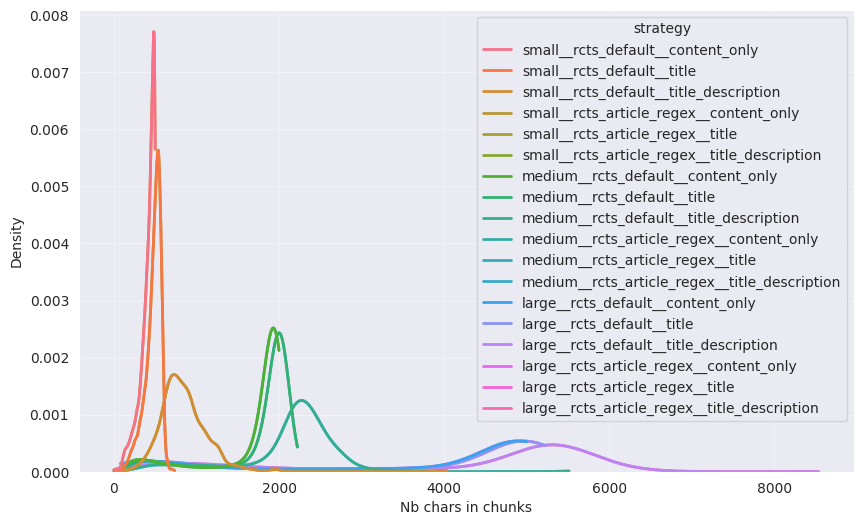

In [13]:
rows = []

for strategy_name, chunks in chunking_results.items():
    for chunk in chunks:
        rows.append({
            "strategy": strategy_name,
            "length": len(chunk.page_content)
        })

df_lengths = pd.DataFrame(rows)

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_lengths,
    x="length",
    hue="strategy",
    common_norm=False,
    cut=0,
    fill=False,
    linewidth=2,
)

plt.xlabel("Nb chars in chunks")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()